# Sistema de Clasificacion de Imagenes: Perros vs Gatos

Este notebook implementa un clasificador de imagenes para distinguir entre perros y gatos usando una red neuronal convolucional (CNN).


## Paso 1: Importacion de librerias

In [ ]:
import os
import random
import shutil
import gc

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import warnings
warnings.filterwarnings('ignore')



I0000 00:00:1781780714.113071    3032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781780714.158142    3032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781780733.712147    3032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781780752.861895    3032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Paso 2: Carga del conjunto de datos

El dataset se descarga desde Kaggle. Tiene mas de 25.000 imagenes en formato .jpg etiquetadas por nombre de archivo (por ejemplo: `cat.0.jpg`, `dog.1.jpg`).

Para este proyecto necesitamos organizar las imagenes en subdirectorios separados por clase, ya que vamos a usar `ImageDataGenerator` con `flow_from_directory()`.

La estructura de carpetas esperada es:

```
dataset/
    train/
        cat/
        dog/
    test/
        cat/
        dog/
```



In [2]:
# Ruta donde estan todas las imagenes originales descargadas de Kaggle
ruta_original = '../data/raw/train'

# Rutas de destino
ruta_train = 'dataset/train/'
ruta_test = 'dataset/test/'

# Creamos las carpetas si no existen
for carpeta in ['cat', 'dog']:
    os.makedirs(os.path.join(ruta_train, carpeta), exist_ok=True)
    os.makedirs(os.path.join(ruta_test, carpeta), exist_ok=True)

# Separamos los archivos por clase
archivos_gato = [f for f in os.listdir(ruta_original) if f.startswith('cat')]
archivos_perro = [f for f in os.listdir(ruta_original) if f.startswith('dog')]

# Mezclamos para que la division sea aleatoria
random.seed(42)
random.shuffle(archivos_gato)
random.shuffle(archivos_perro)

# Usamos el 80% para entrenamiento y el 20% para test
def dividir_y_copiar(archivos, clase, proporcion_train=0.8):
    corte = int(len(archivos) * proporcion_train)
    train_archivos = archivos[:corte]
    test_archivos = archivos[corte:]

    for archivo in train_archivos:
        shutil.copy(os.path.join(ruta_original, archivo),
                    os.path.join(ruta_train, clase, archivo))

    for archivo in test_archivos:
        shutil.copy(os.path.join(ruta_original, archivo),
                    os.path.join(ruta_test, clase, archivo))

    print(f'{clase}: {len(train_archivos)} imagenes de entrenamiento, {len(test_archivos)} de test')

dividir_y_copiar(archivos_gato, 'cat')
dividir_y_copiar(archivos_perro, 'dog')

cat: 2015 imagenes de entrenamiento, 504 de test
dog: 2026 imagenes de entrenamiento, 507 de test


## Paso 3: Visualizacion de las imagenes de entrada

Antes de entrenar cualquier modelo, es importante mirar los datos. Vamos a mostrar las primeras 9 fotos de perros y las primeras 9 de gatos para hacernos una idea de con que estamos trabajando.

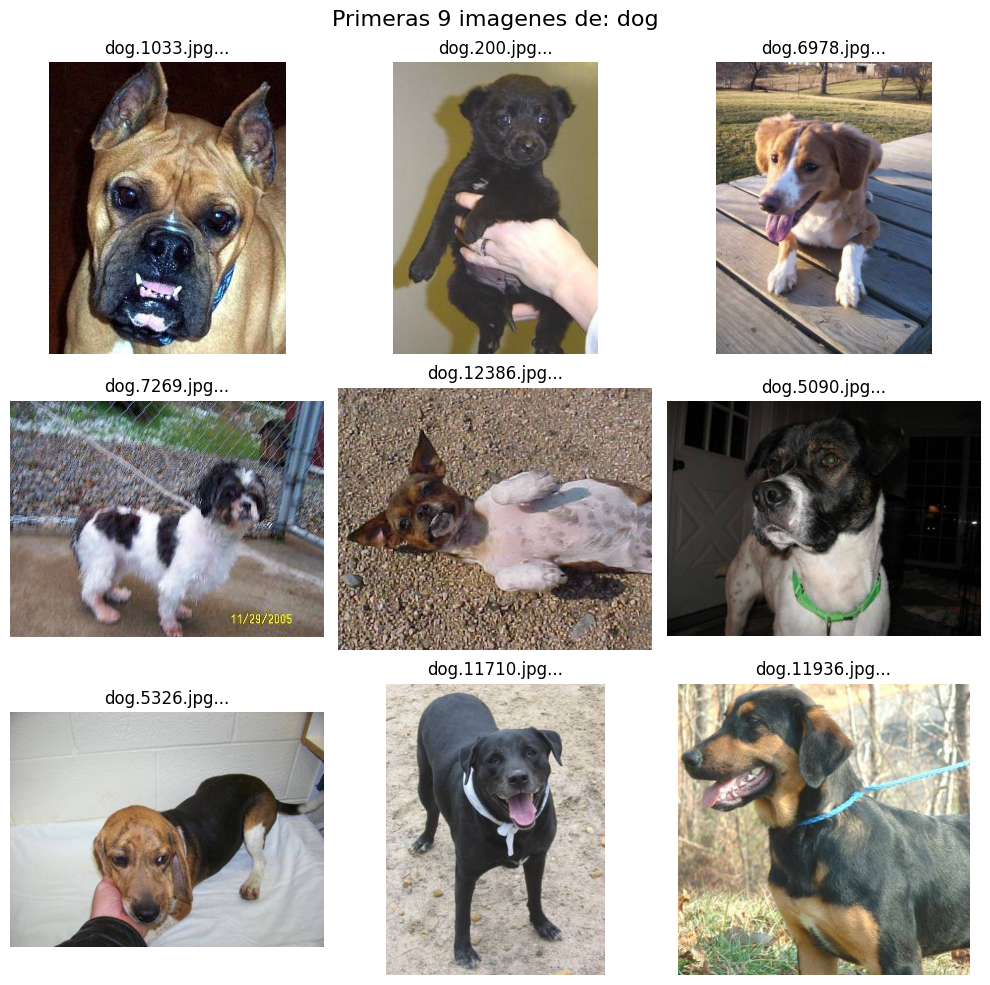

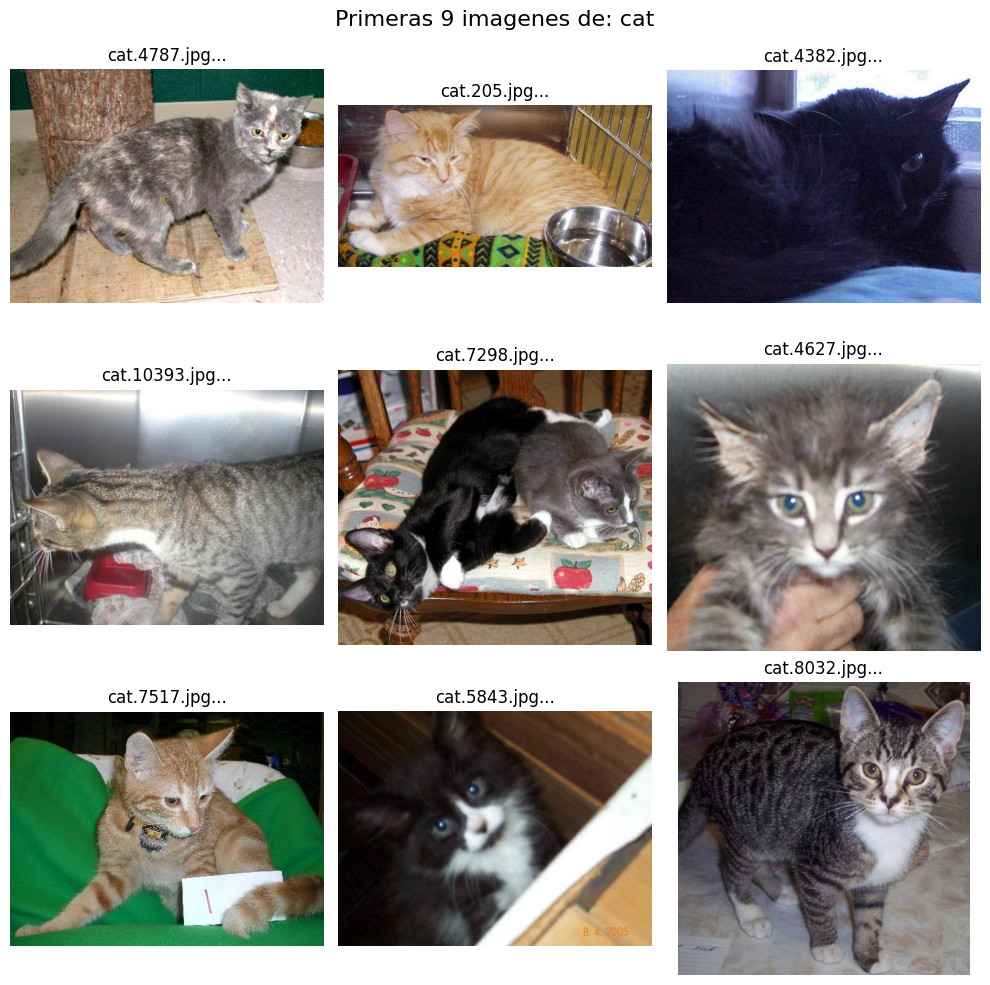

In [3]:
def mostrar_imagenes(clase, ruta_base, n=9):
    """
    Muestra n imagenes de una clase dada en una cuadricula 3x3.
    """
    ruta_clase = os.path.join(ruta_base, clase)
    archivos = os.listdir(ruta_clase)[:n]

    fig, ejes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(f'Primeras {n} imagenes de: {clase}', fontsize=16)

    for i, ax in enumerate(ejes.flat):
        img = load_img(os.path.join(ruta_clase, archivos[i]))
        ax.imshow(img)
        ax.set_title(f'{archivos[i][:15]}...')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Mostramos perros
mostrar_imagenes('dog', ruta_train)

# Mostramos gatos
mostrar_imagenes('cat', ruta_train)

## Paso 4: Preparacion de los datos con ImageDataGenerator

Usamos `ImageDataGenerator` para cargar las imagenes por lotes (batches) en lugar de cargarlas todas a la vez en memoria. Esto es justo lo que necesitamos para no quedarnos sin RAM.

Tambien aplicamos algunas transformaciones al conjunto de entrenamiento para que el modelo aprenda a generalizar mejor (tecnica conocida como data augmentation).

Usamos `class_mode='binary'` porque solo hay dos clases (perro y gato), y la salida del modelo va a ser un unico numero entre 0 y 1 en vez de dos probabilidades.

In [4]:
# Tamano al que vamos a redimensionar todas las imagenes
# 128x128 es bastante mas ligero que el 224x224 tradicional de VGG16
TAMANO = (128, 128)
BATCH_SIZE = 16

# Para el conjunto de entrenamiento aplicamos aumentacion de datos
# Esto ayuda al modelo a no memorizar las imagenes sino aprender rasgos generales
generador_train = ImageDataGenerator(
    rescale=1./255,           # normalizamos los pixeles a rango [0, 1]
    rotation_range=20,        # rotamos ligeramente las imagenes
    horizontal_flip=True,     # les damos la vuelta horizontalmente
    zoom_range=0.15,          # hacemos un ligero zoom aleatorio
    width_shift_range=0.1,    # desplazamos horizontalmente
    height_shift_range=0.1    # desplazamos verticalmente
)

# Para el conjunto de test solo normalizamos, sin transformaciones aleatorias
generador_test = ImageDataGenerator(
    rescale=1./255
)

# Cargamos las imagenes desde las carpetas
# flow_from_directory detecta automaticamente las clases por nombre de subcarpeta
trdata = generador_train.flow_from_directory(
    directory=ruta_train,
    target_size=TAMANO,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

tsdata = generador_test.flow_from_directory(
    directory=ruta_test,
    target_size=TAMANO,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # no mezclamos el test para poder evaluar bien
)

# Mostramos a que clase corresponde cada indice (deberia salir algo como {'cat': 0, 'dog': 1})
print('Clases detectadas:', trdata.class_indices)

Found 4384 images belonging to 2 classes.
Found 1498 images belonging to 2 classes.
Clases detectadas: {'cat': 0, 'dog': 1}


## Paso 5: Construccion del modelo

En la version anterior usabamos la arquitectura completa de VGG16, que tiene mas de 130 millones de parametros (la mayoria concentrados en dos capas densas de 4096 neuronas). Eso es demasiado pesado para correr en un Codespace sin GPU: consume mucha RAM y cada epoca tarda muchisimo.

Aqui usamos una CNN mucho mas pequena pero que sigue la misma idea: bloques de convolucion que van extrayendo caracteristicas, seguidos de una clasificacion final.

- Las capas `Conv2D` detectan patrones visuales (bordes, texturas, formas)
- Las capas `MaxPool2D` reducen el tamano espacial y se quedan con lo mas importante
- `GlobalAveragePooling2D` resume cada mapa de caracteristicas en un solo numero (en vez de aplanar todo con `Flatten`, que generaria un vector enorme)
- `Dropout` apaga aleatoriamente algunas neuronas durante el entrenamiento para evitar que el modelo memorice demasiado los datos de entrenamiento
- La capa final tiene una sola neurona con activacion `sigmoid`, que da un numero entre 0 y 1: cerca de 0 significa gato, cerca de 1 significa perro

Definimos el modelo dentro de una funcion para poder crear una copia nueva cada vez que la necesitemos, sin repetir codigo.

In [5]:
def crear_modelo():
    """
    Crea y compila una CNN pequena para clasificacion binaria (perro vs gato).
    Se usa una funcion para poder generar el mismo modelo varias veces
    sin tener que repetir todo el codigo de la arquitectura.
    """
    modelo = Sequential()

    # Bloque 1
    modelo.add(Conv2D(input_shape=(128, 128, 3), filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
    modelo.add(MaxPool2D(pool_size=(2, 2)))

    # Bloque 2
    modelo.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    modelo.add(MaxPool2D(pool_size=(2, 2)))

    # Bloque 3
    modelo.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
    modelo.add(MaxPool2D(pool_size=(2, 2)))

    # En vez de Flatten (que generaria un vector de miles de valores),
    # usamos GlobalAveragePooling2D para resumir cada mapa de caracteristicas
    modelo.add(GlobalAveragePooling2D())

    # Capa densa de clasificacion, mucho mas pequena que las 4096 unidades de VGG16
    modelo.add(Dense(units=128, activation='relu'))
    modelo.add(Dropout(0.5))

    # Capa de salida: una sola neurona con sigmoid para clasificacion binaria
    modelo.add(Dense(units=1, activation='sigmoid'))

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return modelo


model = crear_modelo()
model.summary()

E0000 00:00:1781780783.625307    3032 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## Paso 6: Entrenamiento del modelo

Entrenamos el modelo con los datos de entrenamiento y evaluamos en el conjunto de test al final de cada epoch.

Limitamos el numero de pasos por epoca con `PASOS_MAX`. Si tienes mas tiempo o mas recursos, puedes subir este numero (o quitar el limite del todo) para usar mas imagenes en cada epoca.

In [6]:
EPOCAS = 5
PASOS_MAX = 100  # tope de pasos por epoca para que el entrenamiento no se haga eterno

# Calculamos cuantos pasos hay por epoch y los limitamos con PASOS_MAX
pasos_train = min(trdata.samples // BATCH_SIZE, PASOS_MAX)
pasos_test = min(tsdata.samples // BATCH_SIZE, PASOS_MAX // 4)

# Entrenamos el modelo
historial = model.fit(
    trdata,
    steps_per_epoch=pasos_train,
    epochs=EPOCAS,
    validation_data=tsdata,
    validation_steps=pasos_test
)

Epoch 1/5


I0000 00:00:1781780784.682775    3032 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 264ms/step - accuracy: 0.4894 - loss: 0.6956 - val_accuracy: 1.0000 - val_loss: 0.6753
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 403ms/step - accuracy: 0.5194 - loss: 0.6931 - val_accuracy: 0.0150 - val_loss: 0.8096
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.5549 - loss: 0.6871 - val_accuracy: 1.0000 - val_loss: 0.6111
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.5494 - loss: 0.6871 - val_accuracy: 0.3275 - val_loss: 0.7314
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 406ms/step - accuracy: 0.5587 - loss: 0.6841 - val_accuracy: 0.2900 - val_loss: 0.7299


## Paso 7: Visualizacion del entrenamiento

Graficamos la evolucion del accuracy y la perdida durante el entrenamiento para ver si el modelo ha aprendido bien o si hay sobreajuste (overfitting).

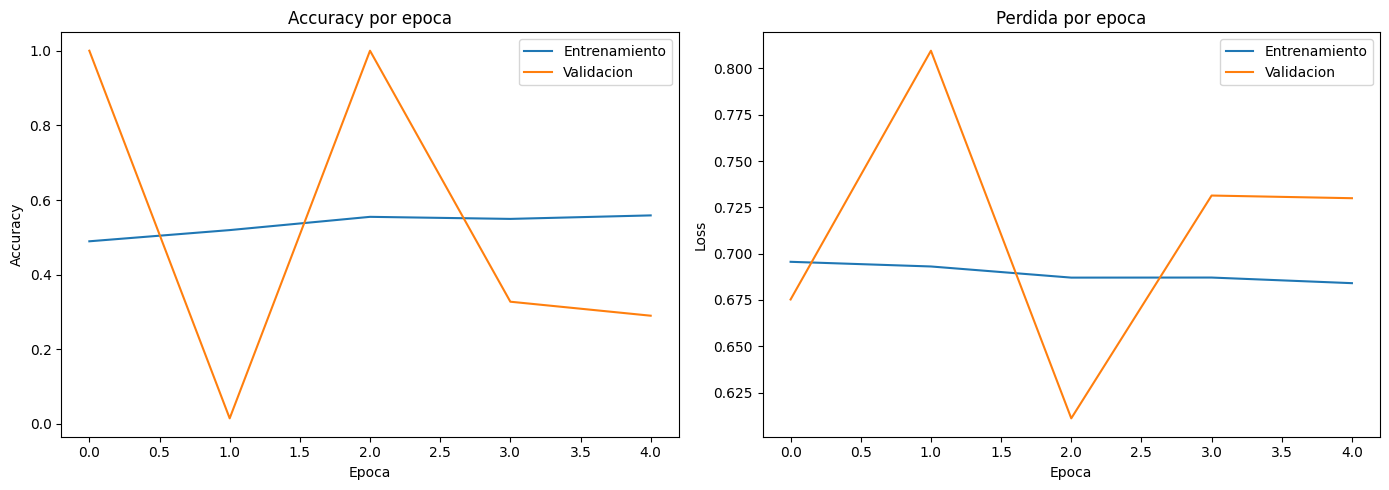

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de accuracy
ejes[0].plot(historial.history['accuracy'], label='Entrenamiento')
ejes[0].plot(historial.history['val_accuracy'], label='Validacion')
ejes[0].set_title('Accuracy por epoca')
ejes[0].set_xlabel('Epoca')
ejes[0].set_ylabel('Accuracy')
ejes[0].legend()

# Grafico de perdida
ejes[1].plot(historial.history['loss'], label='Entrenamiento')
ejes[1].plot(historial.history['val_loss'], label='Validacion')
ejes[1].set_title('Perdida por epoca')
ejes[1].set_xlabel('Epoca')
ejes[1].set_ylabel('Loss')
ejes[1].legend()

plt.tight_layout()
plt.show()

## Paso 8: Optimizacion del modelo con callbacks

Volvemos a entrenar el modelo pero esta vez con dos callbacks:

- **ModelCheckpoint**: guarda automaticamente el mejor modelo segun la perdida de validacion
- **EarlyStopping**: para el entrenamiento si el modelo deja de mejorar, evitando overfitting y tiempo de computo desperdiciado

Antes de crear el segundo modelo, liberamos de memoria el primero. Esto es importante porque si no, tendriamos dos modelos cargados en RAM al mismo tiempo.

In [8]:
# Liberamos memoria del primer modelo antes de crear el segundo
del model
tf.keras.backend.clear_session()
gc.collect()

# Creamos un modelo nuevo con la misma arquitectura, usando la funcion del Paso 5
model2 = crear_modelo()

# Guardamos el mejor modelo automaticamente
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo.keras',   # nombre del archivo donde se guarda
    monitor='val_loss',              # vigilamos la perdida en validacion
    save_best_only=True,             # solo guardamos si mejora
    mode='min',                      # queremos que val_loss baje
    verbose=1
)

# Paramos si el modelo no mejora durante 3 epocas seguidas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,       # cuantas epocas esperamos sin mejora antes de parar
    mode='min',
    verbose=1
)

# Entrenamos pasando los callbacks
historial2 = model2.fit(
    trdata,
    steps_per_epoch=pasos_train,
    epochs=15,                # ponemos mas epocas porque EarlyStopping lo para cuando toque
    validation_data=tsdata,
    validation_steps=pasos_test,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.4840 - loss: 0.6964
Epoch 1: val_loss improved from None to 0.70670, saving model to mejor_modelo.keras

Epoch 1: finished saving model to mejor_modelo.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 260ms/step - accuracy: 0.4906 - loss: 0.6950 - val_accuracy: 0.0000e+00 - val_loss: 0.7067
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4937 - loss: 0.6927
Epoch 2: val_loss did not improve from 0.70670
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 254ms/step - accuracy: 0.5144 - loss: 0.6918 - val_accuracy: 0.0000e+00 - val_loss: 0.8272
Epoch 3/15
 74/100 ━━━━━━━━━━━━━━━━━━━━ 10s 386ms/step - accuracy: 0.5345 - loss: 0.6897
Epoch 3: val_loss did not improve from 0.70670
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 411ms/step - accuracy: 0.5498 - loss: 0.6847 - val_accuracy: 0.5800 - val_loss: 0.7074
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5389 - loss: 0.6812
Epoch 4: val_loss did not improve from 0.70670


## Paso 9: Visualizacion del segundo entrenamiento

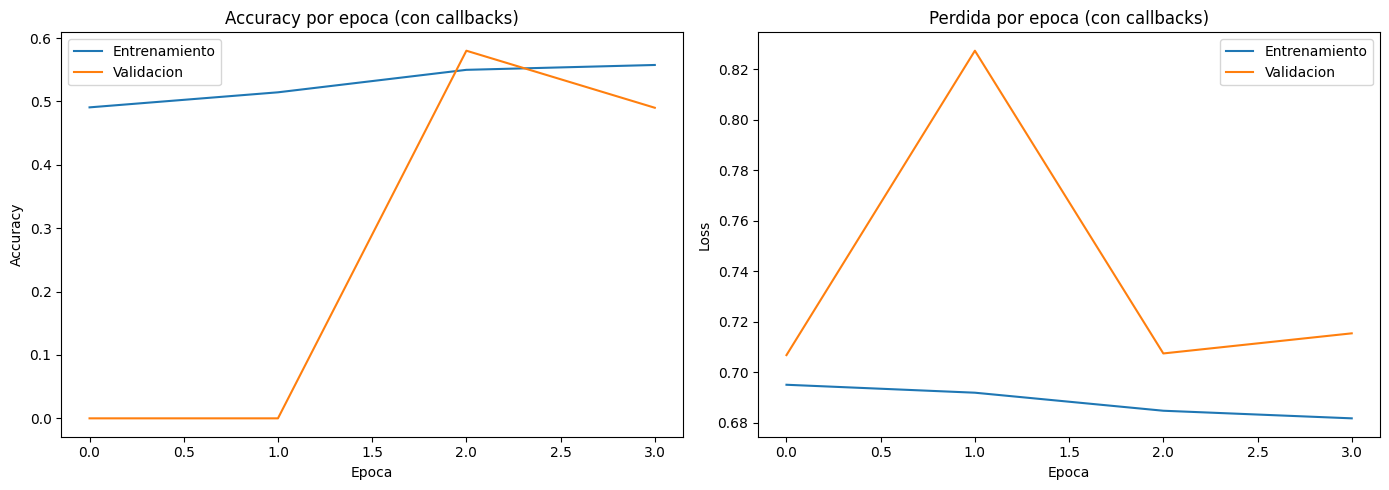

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].plot(historial2.history['accuracy'], label='Entrenamiento')
ejes[0].plot(historial2.history['val_accuracy'], label='Validacion')
ejes[0].set_title('Accuracy por epoca (con callbacks)')
ejes[0].set_xlabel('Epoca')
ejes[0].set_ylabel('Accuracy')
ejes[0].legend()

ejes[1].plot(historial2.history['loss'], label='Entrenamiento')
ejes[1].plot(historial2.history['val_loss'], label='Validacion')
ejes[1].set_title('Perdida por epoca (con callbacks)')
ejes[1].set_xlabel('Epoca')
ejes[1].set_ylabel('Loss')
ejes[1].legend()

plt.tight_layout()
plt.show()

## Paso 10: Carga del mejor modelo y predicciones

Cargamos el mejor modelo guardado por `ModelCheckpoint` y lo usamos para predecir sobre el conjunto de test.

In [10]:
# Cargamos el modelo que guardamos durante el entrenamiento
mejor_modelo = load_model('mejor_modelo.keras')

# Evaluamos en el conjunto de test
perdida, accuracy = mejor_modelo.evaluate(tsdata, steps=pasos_test)
print(f'\nResultados en el conjunto de test:')
print(f'  Perdida: {perdida:.4f}')
print(f'  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.0000e+00 - loss: 0.7067

Resultados en el conjunto de test:
  Perdida: 0.7067
  Accuracy: 0.0000 (0.00%)


## Paso 11: Prediccion sobre imagenes individuales

Probamos el modelo con algunas imagenes concretas para ver como clasifica.

Como la salida del modelo es una sola neurona con `sigmoid` (un numero entre 0 y 1), no podemos usar `argmax` como hariamos con varias clases. En su lugar, comparamos ese numero con 0.5: si es mayor, predecimos perro; si es menor, predecimos gato.

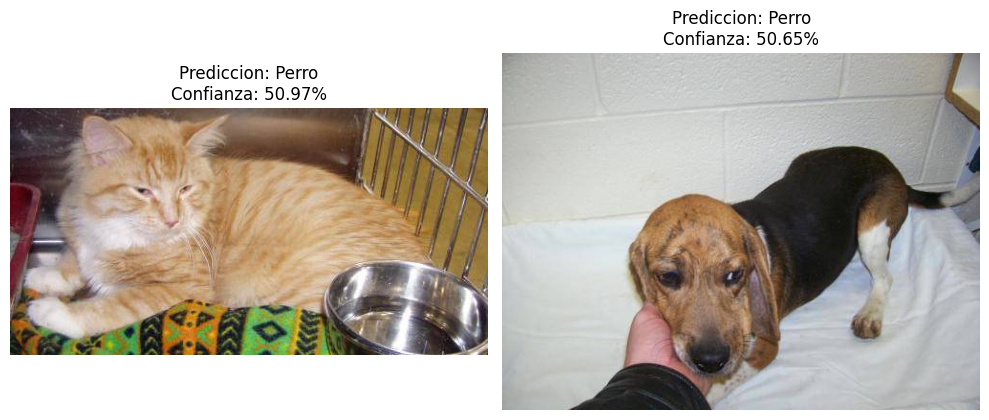

In [11]:
# Segun trdata.class_indices, el gato deberia ser la clase 0 y el perro la clase 1
clases = {0: 'Gato', 1: 'Perro'}

def predecir_imagen(ruta_imagen, modelo, tamano=(128, 128)):
    """
    Carga una imagen, la preprocesa y devuelve la prediccion del modelo.
    Como el modelo tiene una sola salida (sigmoid), el valor representa
    la probabilidad de que la imagen sea un perro.
    """
    img = load_img(ruta_imagen, target_size=tamano)
    img_array = img_to_array(img) / 255.0           # normalizamos igual que en el entrenamiento
    img_array = np.expand_dims(img_array, axis=0)   # anadimos dimension de batch

    probabilidad_perro = modelo.predict(img_array, verbose=0)[0][0]

    if probabilidad_perro > 0.5:
        clase_predicha = 1
        confianza = probabilidad_perro
    else:
        clase_predicha = 0
        confianza = 1 - probabilidad_perro

    return clases[clase_predicha], confianza


# Probamos con algunas imagenes del test
imagenes_prueba = [
    os.path.join(ruta_test, 'cat', os.listdir(os.path.join(ruta_test, 'cat'))[0]),
    os.path.join(ruta_test, 'dog', os.listdir(os.path.join(ruta_test, 'dog'))[0]),
]

fig, ejes = plt.subplots(1, len(imagenes_prueba), figsize=(10, 5))

for i, ruta in enumerate(imagenes_prueba):
    clase, confianza = predecir_imagen(ruta, mejor_modelo)
    img = load_img(ruta)
    ejes[i].imshow(img)
    ejes[i].set_title(f'Prediccion: {clase}\nConfianza: {confianza:.2%}')
    ejes[i].axis('off')

plt.tight_layout()
plt.show()

## Paso 12: Guardado del modelo

Guardamos el modelo definitivo en disco para poder usarlo en el futuro sin tener que volver a entrenarlo.

In [12]:
# Creamos la carpeta de modelos si no existe
os.makedirs('modelos', exist_ok=True)

# Guardamos el mejor modelo en la carpeta
ruta_guardado = '../models/clasificador_perros_gatos.keras'
mejor_modelo.save(ruta_guardado)
print(f'Modelo guardado correctamente en: {ruta_guardado}')

Modelo guardado correctamente en: ../models/clasificador_perros_gatos.keras


## Resumen

En este notebook hemos hecho lo siguiente:

1. Descargamos y organizamos el dataset de perros y gatos
2. Visualizamos las imagenes para entender con que datos trabajamos
3. Preparamos los datos usando `ImageDataGenerator` para no saturar la memoria RAM
4. Construimos una CNN pequena y ligera, mas adecuada para entornos sin GPU como Codespaces
5. Entrenamos el modelo y visualizamos su evolucion
6. Optimizamos el entrenamiento con `ModelCheckpoint` y `EarlyStopping`, liberando memoria entre entrenamientos
7. Cargamos el mejor modelo y lo evaluamos sobre el conjunto de test
8. Guardamos el modelo para uso futuro

Al ser un modelo mucho mas simple que VGG16, es normal que el accuracy final sea algo menor (probablemente entre 70-85% en vez de 80-90%), pero a cambio se entrena en una fraccion del tiempo y sin riesgo de quedarse sin memoria.